# 04 -- Modelling

**Goal:** predict `points_finish` (top-10 finish, binary) using the
feature-ready data `03_feature_engineering.ipynb` saved -- 22 numeric
features now (23 with `country_code`), up from 12 last time this
notebook ran, thanks to three new rounds of feature engineering (rolling
pace/positions-gained features, championship standings before each race),
all done in `03_feature_engineering.ipynb`.

**Inputs from notebook 03:** `train.csv`, `test.csv`, and
`feature_config.json` -- this notebook doesn't redefine the feature list
or redo the train/test split, it just loads what 03 already decided.

**Models tried:** Dummy baseline -> Logistic Regression -> Random Forest ->
XGBoost, compared side by side, with the winner saved for the dashboard
in `app/dashboard.py`.


In [1]:
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay,
)


---
## Section 1 -- Configuration

The feature list isn't redefined here -- it's loaded from
`feature_config.json`, the file notebook 03 saved. If notebook 03 ever
adds another feature, this notebook picks it up automatically instead of
needing to be edited to match.


In [2]:
PATHS = {
    'train_input': '../data/processed/train.csv',
    'test_input': '../data/processed/test.csv',
    'feature_config': '../data/processed/feature_config.json',
    'plots': '../data/figures/',
    'models': '../models/',
}

with open(PATHS['feature_config']) as f:
    feature_config = json.load(f)

TARGET = feature_config['target']
NUMERIC_FEATURES = feature_config['numeric_features']
CATEGORICAL_FEATURES = feature_config['categorical_features']
ALL_FEATURES = feature_config['all_features']

print(f"Target: {TARGET}")
print(f"Numeric features ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}")
print(f"Categorical features: {CATEGORICAL_FEATURES}")


Target: points_finish
Numeric features (22): ['grid_position', 'best_qual_time_s', 'air_temp_max', 'track_temp_min', 'wind_speed_mean', 'winddirection_mean', 'track_temp_range', 'season_progress', 'driver_form_points_last5', 'driver_points_finish_rate_last5', 'driver_dnf_rate_last5', 'driver_grid_position_last5', 'driver_teammate_gap_last5', 'driver_season_avg_points_so_far', 'driver_positions_gained_last5', 'driver_pace_ratio_last5', 'constructor_form_points_last5', 'constructor_dnf_rate_last5', 'constructor_avg_pit_duration_last5', 'driver_standing_before_race', 'constructor_standing_before_race', 'constructor_points_finish_rate']
Categorical features: ['country_code']


---
## Section 2 -- Load Train/Test Data

Loads the exact rows `03_feature_engineering.ipynb` already split by
season -- no re-splitting here, that decision (and the leakage-avoidance
reasoning behind it) lives in one place, not two.


In [3]:
train_df = pd.read_csv(PATHS['train_input'])
test_df = pd.read_csv(PATHS['test_input'])

print(f"Train: {train_df.shape[0]:,} rows ({sorted(train_df['year'].unique())})")
print(f"Test:  {test_df.shape[0]:,} rows ({sorted(test_df['year'].unique())})")
print()
print("Train target balance:")
print(train_df[TARGET].value_counts(normalize=True).round(3))
print("Test target balance:")
print(test_df[TARGET].value_counts(normalize=True).round(3))

X_train, y_train = train_df[ALL_FEATURES], train_df[TARGET]
X_test, y_test = test_df[ALL_FEATURES], test_df[TARGET]


Train: 1,359 rows ([2022, 2023, 2024])
Test:  479 rows ([2025])

Train target balance:
points_finish
True     0.5
False    0.5
Name: proportion, dtype: float64
Test target balance:
points_finish
True     0.501
False    0.499
Name: proportion, dtype: float64


---
## Section 3 -- Preprocessing Pipeline

`ColumnTransformer` handles numeric and categorical columns differently
in one object, fit only on `X_train` -- median and one-hot categories
come from training data only, so no test-set information leaks into
preprocessing. This now also covers the 4 new rolling features, which get
imputed with the training-set median exactly like every other partially-
missing numeric column -- see notebook 03 Section 5 for why that's the
right call for them specifically.


In [4]:
numeric_transformer = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encode', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, NUMERIC_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES),
])


---
## Section 4 -- Helper Functions

Every model from here on needs the same things done to it: wrapped in the
same preprocessing pipeline, evaluated with the same metrics, and plotted
the same way. Writing each of those once as a function -- instead of
copy-pasting the same block for every new model -- means adding a new
model later is a few lines, not a duplicated section. It also removes a
real bug risk: if every model reused a generic variable name like `model`
or `preds`, trying the next model would silently overwrite the previous
one's results before they could ever be compared.


In [5]:
# Collects one result dict per model, so every model tried in this
# notebook can be compared side by side later -- see Section 9.
results = []


def evaluate_classifier(name, y_true, y_pred, y_proba=None):
    # Prints the same numbers for every model, so results are directly
    # comparable no matter which model produced them.
    accuracy = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"{name} accuracy: {accuracy:.3f}")
    print(f"{name} F1:       {f1:.3f}")

    result = {'model': name, 'accuracy': accuracy, 'f1': f1}

    if y_proba is not None:
        roc_auc = roc_auc_score(y_true, y_proba)
        print(f"{name} ROC-AUC:  {roc_auc:.3f}")
        result['roc_auc'] = roc_auc

    print()
    print(classification_report(y_true, y_pred))

    return result


def build_model_pipeline(estimator):
    # Reuses the same preprocessing (impute + scale numeric, impute +
    # one-hot categorical) for every model -- only the classifier at the
    # end changes.
    return Pipeline(steps=[
        ('preprocess', preprocessor),
        ('classify', estimator),
    ])


def plot_confusion(name, y_true, y_pred, filename):
    fig, ax = plt.subplots(figsize=(5, 5))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=ax, cmap='Blues')
    ax.set_title(f'{name} -- Confusion Matrix (2025 test set)')
    plt.tight_layout()
    plt.savefig(f"{PATHS['plots']}{filename}", dpi=130, bbox_inches='tight')
    plt.show()


def plot_roc_curve(name, y_true, y_proba, ax):
    # Draws one model's ROC curve onto a shared axis, so multiple models
    # can be compared on the same chart -- see Section 9.
    RocCurveDisplay.from_predictions(y_true, y_proba, name=name, ax=ax)


---
## Section 5 -- Baseline: Dummy Classifier

### Why bother with a model that doesn't even look at the data?

Before trusting any accuracy number from a real model, you need a floor
to compare against. `DummyClassifier(strategy='most_frequent')` always
predicts the majority class -- on a near-50/50 target that's close to a
coin flip, around 50% accuracy. Any real model has to clear this bar by a
meaningful margin, or it isn't actually learning anything from the
features.


In [6]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_preds = dummy.predict(X_test)
dummy_proba = dummy.predict_proba(X_test)[:, 1]

results.append(evaluate_classifier('Dummy classifier', y_test, dummy_preds, dummy_proba))


Dummy classifier accuracy: 0.501
Dummy classifier F1:       0.668
Dummy classifier ROC-AUC:  0.500



              precision    recall  f1-score   support

       False       0.00      0.00      0.00       239
        True       0.50      1.00      0.67       240

    accuracy                           0.50       479
   macro avg       0.25      0.50      0.33       479
weighted avg       0.25      0.50      0.33       479



C:\Users\johar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\johar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\johar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

---
## Section 6 -- Logistic Regression Baseline

### Why logistic regression first?

Simplest real model for binary classification -- interpretable
coefficients, fast to fit, no hyperparameter tuning needed for a first
pass. If this beats the dummy baseline by a real margin, that's proof
the 22 features actually carry predictive signal. Fancier models (trees,
boosting) come next, once there's a working baseline to compare them
against -- `build_model_pipeline` (Section 4) means trying one is just a
different estimator passed in, not a rewritten pipeline.


In [7]:
logreg = build_model_pipeline(LogisticRegression(max_iter=1000))
logreg.fit(X_train, y_train)
logreg_preds = logreg.predict(X_test)
logreg_proba = logreg.predict_proba(X_test)[:, 1]

results.append(evaluate_classifier('Logistic regression', y_test, logreg_preds, logreg_proba))


Logistic regression accuracy: 0.747
Logistic regression F1:       0.719
Logistic regression ROC-AUC:  0.831

              precision    recall  f1-score   support

       False       0.70      0.85      0.77       239
        True       0.81      0.65      0.72       240

    accuracy                           0.75       479
   macro avg       0.76      0.75      0.74       479
weighted avg       0.76      0.75      0.74       479



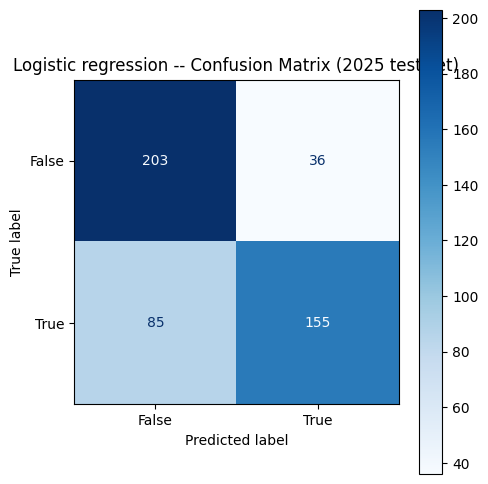

In [8]:
plot_confusion('Logistic regression', y_test, logreg_preds, 'model_01_logreg_confusion_matrix.png')


---
## Section 7 -- Random Forest

### Why try a tree-based model?

Logistic regression can only draw a straight-line boundary between
"scores points" and "doesn't" -- it assumes each feature's effect is
independent and additive. A Random Forest builds many decision trees,
each asking a sequence of yes/no questions (`grid_position <= 5?`, then
`driver_form_points_last5 > 10?`, ...), which lets it pick up
*interactions* logistic regression can't -- e.g. maybe recent good form
matters more from a good grid slot than a bad one. `class_weight='balanced'`
is included here as the safe default for every classifier built with this
pattern, even though `points_finish` is already close to 50/50.


In [9]:
rf = build_model_pipeline(RandomForestClassifier(
    n_estimators=300, max_depth=6, random_state=42, class_weight='balanced',
))
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

results.append(evaluate_classifier('Random Forest', y_test, rf_preds, rf_proba))


Random Forest accuracy: 0.731
Random Forest F1:       0.701
Random Forest ROC-AUC:  0.831

              precision    recall  f1-score   support

       False       0.69      0.83      0.76       239
        True       0.79      0.63      0.70       240

    accuracy                           0.73       479
   macro avg       0.74      0.73      0.73       479
weighted avg       0.74      0.73      0.73       479



---
## Section 8 -- XGBoost

### Why try boosting on top of a Random Forest?

A Random Forest builds all its trees independently and averages them.
Gradient boosting builds trees one at a time, and each new tree focuses
specifically on correcting the mistakes the previous trees made -- a
chain of corrections rather than a crowd of independent guesses. That
usually squeezes out a bit more accuracy than a Random Forest, at the
cost of being more sensitive to its settings. `learning_rate=0.05` keeps
each correction small and gradual, a safer default than a large one.


In [10]:
xgb = build_model_pipeline(XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    random_state=42, eval_metric='logloss',
))
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)
xgb_proba = xgb.predict_proba(X_test)[:, 1]

results.append(evaluate_classifier('XGBoost', y_test, xgb_preds, xgb_proba))


XGBoost accuracy: 0.745
XGBoost F1:       0.739
XGBoost ROC-AUC:  0.809

              precision    recall  f1-score   support

       False       0.73      0.77      0.75       239
        True       0.76      0.72      0.74       240

    accuracy                           0.75       479
   macro avg       0.75      0.75      0.75       479
weighted avg       0.75      0.75      0.75       479



---
## Section 9 -- Model Comparison

Every model's numbers landed in `results` as it was evaluated -- laying
them out side by side, plus overlaying all four ROC curves on one chart,
is what actually answers the question this notebook started with: do the
22 features (8 pre-race + 13 rolling/standings + 1 target-encoded) carry
real signal, and which model uses them best?

A ROC curve shows how well a model separates the two classes across
*every* possible decision threshold, not just the default 50% cutoff.
The dummy classifier's curve is the literal diagonal line "random
guessing" draws -- every other curve bowing above that diagonal is the
visual proof of a model that actually learned something.


In [11]:
fitted_models = {
    'Dummy classifier': (dummy, dummy_preds, dummy_proba),
    'Logistic regression': (logreg, logreg_preds, logreg_proba),
    'Random Forest': (rf, rf_preds, rf_proba),
    'XGBoost': (xgb, xgb_preds, xgb_proba),
}

results_df = pd.DataFrame(results).sort_values('f1', ascending=False).reset_index(drop=True)
print(results_df)

best_model_name = results_df.iloc[0]['model']
best_f1 = results_df.iloc[0]['f1']
dummy_f1 = results_df.loc[results_df['model'] == 'Dummy classifier', 'f1'].values[0]

print(f"\nBest model: {best_model_name} (+{best_f1 - dummy_f1:.3f} F1 over the dummy baseline)")

best_pipeline, best_preds, best_proba = fitted_models[best_model_name]


                 model  accuracy        f1   roc_auc
0              XGBoost  0.745303  0.739316  0.809484
1  Logistic regression  0.747390  0.719258  0.831433
2        Random Forest  0.730689  0.700696  0.830614
3     Dummy classifier  0.501044  0.667594  0.500000

Best model: XGBoost (+0.072 F1 over the dummy baseline)


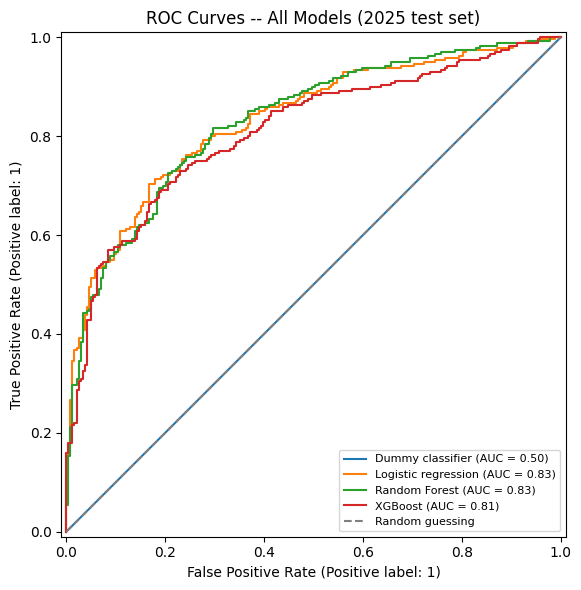

In [12]:
fig, ax = plt.subplots(figsize=(6, 6))

plot_roc_curve('Dummy classifier', y_test, dummy_proba, ax)
plot_roc_curve('Logistic regression', y_test, logreg_proba, ax)
plot_roc_curve('Random Forest', y_test, rf_proba, ax)
plot_roc_curve('XGBoost', y_test, xgb_proba, ax)

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guessing')
ax.set_title('ROC Curves -- All Models (2025 test set)')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig(f"{PATHS['plots']}model_02_roc_comparison.png", dpi=130, bbox_inches='tight')
plt.show()


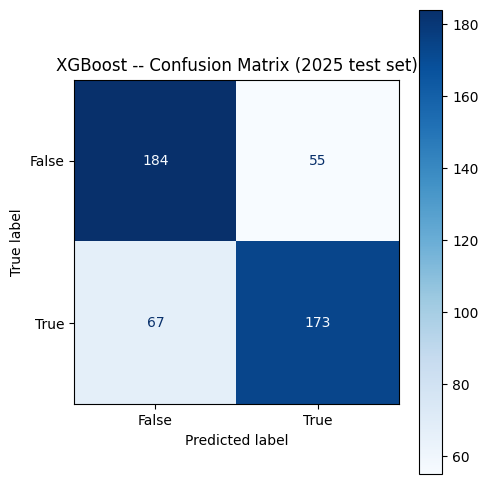

In [13]:
plot_confusion(best_model_name, y_test, best_preds, 'model_03_best_confusion_matrix.png')


---
## Section 10 -- What Actually Drove the Winning Model?

Accuracy tells you a model works; feature importance tells you *why*.
For a tree-based model, importance measures how much each feature reduced
prediction error, averaged across every split in every tree it used that
feature for -- a feature the model leaned on heavily gets a high score,
one it barely touched gets close to zero. Logistic regression doesn't
have "importance" in the same sense, but its coefficients play the same
role: how much the prediction shifts per unit change in that feature.
This is also the chart that answers the real question behind today's
work: did the newest features (rolling pace/positions-gained,
championship standings) actually matter, or did the original 8 still
dominate? Worth a specific look at `driver_standing_before_race` /
`constructor_standing_before_race` here -- notebook 03 flagged them as
the highest-redundancy features added (r=0.88-0.89 with other features
already in the model), the same kind of multicollinearity that caused an
earlier F1-vs-ROC-AUC split in this notebook.


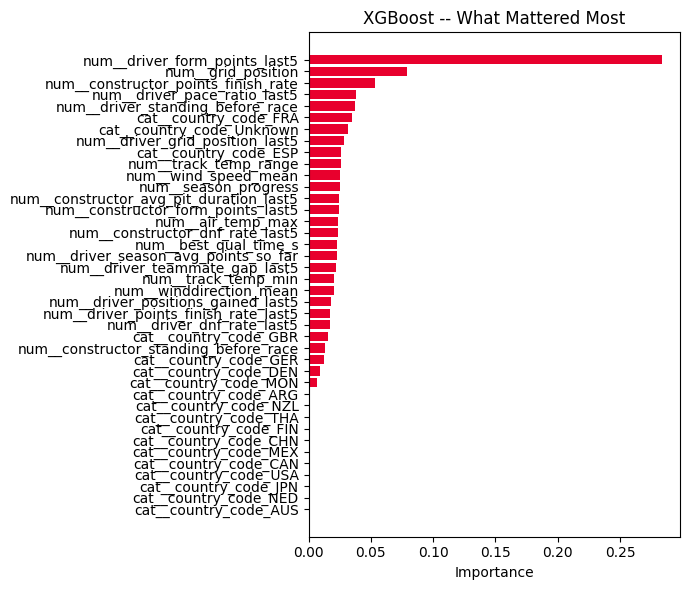

In [14]:
classifier = best_pipeline.named_steps['classify']
feature_names = best_pipeline.named_steps['preprocess'].get_feature_names_out()

if hasattr(classifier, 'feature_importances_'):
    importance = classifier.feature_importances_
    importance_label = 'Importance'
else:
    importance = classifier.coef_[0]
    importance_label = 'Coefficient'

importance_df = pd.DataFrame({
    'feature': feature_names,
    importance_label: importance,
}).sort_values(importance_label, ascending=True)

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(importance_df['feature'], importance_df[importance_label], color='#e8002d')
ax.set_title(f'{best_model_name} -- What Mattered Most')
ax.set_xlabel(importance_label)
plt.tight_layout()
plt.savefig(f"{PATHS['plots']}model_04_feature_importance.png", dpi=130, bbox_inches='tight')
plt.show()


---
## Section 11 -- Save the Final Model

Saves the winning *fitted pipeline* (preprocessing + classifier together)
so the dashboard can load one file and call `.predict_proba()` directly on
raw feature values -- it doesn't need to know anything about imputing,
scaling, or one-hot encoding, the pipeline already handles that
internally. A small metadata file goes alongside it with the exact
feature list (so the dashboard builds its input form in the right order)
and the `country_code` values seen during training (so its dropdown never
offers a category the model has never seen).


In [15]:
MODELS_DIR = Path(PATHS['models'])
MODELS_DIR.mkdir(exist_ok=True)

joblib.dump(best_pipeline, MODELS_DIR / 'final_model.joblib')

metadata = {
    'model_name': best_model_name,
    'target': TARGET,
    'numeric_features': NUMERIC_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'all_features': ALL_FEATURES,
    'country_code_options': sorted(train_df['country_code'].dropna().unique().tolist()),
    'test_accuracy': float(results_df.iloc[0]['accuracy']),
    'test_f1': float(results_df.iloc[0]['f1']),
}
with open(MODELS_DIR / 'model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

# Full comparison table (all 4 models, not just the winner) -- the
# dashboard's Model Performance tab reads this directly rather than
# recomputing anything itself.
results_df.to_csv(MODELS_DIR / 'model_comparison.csv', index=False)

print(f"Saved {best_model_name} pipeline -> {MODELS_DIR / 'final_model.joblib'}")
print(f"Saved metadata -> {MODELS_DIR / 'model_metadata.json'}")
print(f"Saved comparison table -> {MODELS_DIR / 'model_comparison.csv'}")


Saved XGBoost pipeline -> ..\models\final_model.joblib
Saved metadata -> ..\models\model_metadata.json
Saved comparison table -> ..\models\model_comparison.csv


---
## Section 12 -- Is the Default 0.5 Threshold Actually the Right One?

Every prediction above used `.predict()`, which applies a fixed 50% cutoff to
the model's probability under the hood -- if the winning model is 51% sure a
driver finishes top 10, that already counts as a "yes," no different from
99% sure. That cutoff was never chosen for a reason, it's just scikit-learn's
default.

`precision_recall_curve` checks what precision and recall actually look like
at *every* possible cutoff from 0 to 1, using the real 2025 test-set
probabilities (`best_proba`) -- so instead of guessing whether 0.5 is a good
line to draw, it can be checked directly, then a decision made from that.


In [16]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, best_proba)

# precision_recall_curve returns one more precision/recall pair than it does
# thresholds (the last pair is for "cutoff so high nothing is ever predicted
# True"), so f1_scores[:-1] lines up 1-to-1 with the actual thresholds tried.
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)
f1_scores = np.nan_to_num(f1_scores)  # 0/0 at the precision=recall=0 end

best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
best_threshold_f1 = f1_scores[best_idx]

default_f1 = f1_score(y_test, best_preds)

print(f"Default threshold (0.50):         F1 = {default_f1:.3f}")
print(f"Best threshold found ({best_threshold:.2f}):    F1 = {best_threshold_f1:.3f}")
print(f"Precision at best threshold:      {precisions[best_idx]:.3f}")
print(f"Recall at best threshold:         {recalls[best_idx]:.3f}")


Default threshold (0.50):         F1 = 0.739
Best threshold found (0.27):    F1 = 0.751
Precision at best threshold:      0.673
Recall at best threshold:         0.850


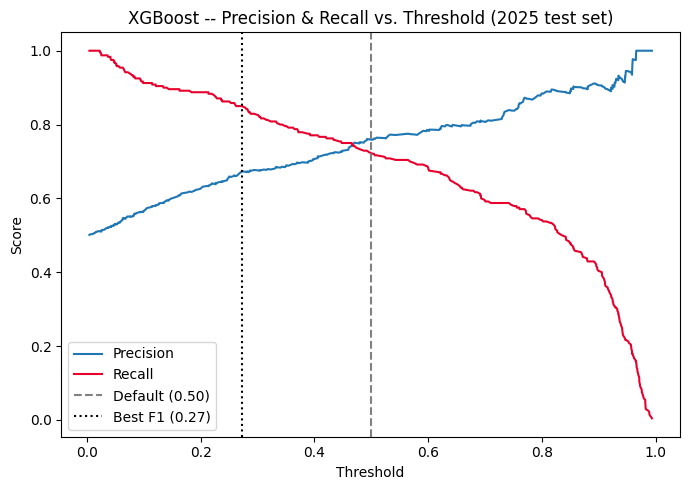

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(thresholds, precisions[:-1], label='Precision', color='#1f77b4')
ax.plot(thresholds, recalls[:-1], label='Recall', color='#e8002d')
ax.axvline(0.5, color='gray', linestyle='--', label='Default (0.50)')
ax.axvline(best_threshold, color='black', linestyle=':',
           label=f'Best F1 ({best_threshold:.2f})')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title(f'{best_model_name} -- Precision & Recall vs. Threshold (2025 test set)')
ax.legend()
plt.tight_layout()
plt.savefig(f"{PATHS['plots']}model_05_threshold_tuning.png", dpi=130, bbox_inches='tight')
plt.show()


**Real result, not a guess:** the best threshold found is **0.27**, not 0.50 --
F1 improves from 0.739 to 0.751. But that small F1 gain is bought with a much
bigger shift underneath it:

```
threshold=0.50:  precision=0.759  recall=0.721  (228 drivers predicted "top 10")
threshold=0.27:  precision=0.671  recall=0.850  (304 drivers predicted "top 10")
```

Moving the line down means the model calls "top 10!" for 76 more drivers than
before. It catches noticeably more of the real top-10 finishers (72% -> 85%
recall) but is right less often when it makes that call (76% -> 67% precision).
The F1 number barely moved (+0.011) but the model's actual behaviour changed a
lot -- **F1 alone hides this.**

Whether 0.27 is actually "better" depends on what the prediction is *for*,
which isn't a question a metric can answer:
- Want the dashboard to only say "top 10!" when it's fairly confident, and
  accept it'll miss some? Closer to 0.50 (or higher).
- Want it to flag every driver with a real shot, even at the cost of more
  wrong calls? Closer to 0.27.

`app/dashboard.py` currently hardcodes 0.5 (`prediction = "Points finish" if
probability >= 0.5 else "No points"`) -- not changed here, since that's a
call about what the dashboard should optimise for, not a number to pick
automatically.


---
## Section 13 -- A Second Target: Predicting the Podium (on_podium)

Everything above predicts `points_finish` -- top 10. `on_podium` asks a
harder, rarer question: does this driver finish in the **top 3**? Same
pre-race features, same leakage rules, same helper functions from Section
4 -- only the target column and the class balance change.

That balance change matters: `points_finish` was almost exactly 50/50,
but only 15% of driver-races end on the podium. A model that just guessed
"no" every time would already be 85% accurate without learning anything,
so `class_weight='balanced'` (already used for Random Forest above) and
its XGBoost equivalent, `scale_pos_weight`, matter a lot more here than
they did for the points-finish target.


In [18]:
y_train_podium = train_df['on_podium']
y_test_podium = test_df['on_podium']

print(f"Podium rate, train: {y_train_podium.mean():.1%}")
print(f"Podium rate, test:  {y_test_podium.mean():.1%}")


Podium rate, train: 15.0%
Podium rate, test:  15.0%


In [19]:
podium_results = []

dummy_podium = DummyClassifier(strategy='most_frequent')
dummy_podium.fit(X_train, y_train_podium)
podium_results.append(evaluate_classifier(
    'Dummy classifier', y_test_podium,
    dummy_podium.predict(X_test), dummy_podium.predict_proba(X_test)[:, 1],
))

logreg_podium = build_model_pipeline(
    LogisticRegression(max_iter=1000, class_weight='balanced')
)
logreg_podium.fit(X_train, y_train_podium)
logreg_podium_preds = logreg_podium.predict(X_test)
logreg_podium_proba = logreg_podium.predict_proba(X_test)[:, 1]
podium_results.append(evaluate_classifier(
    'Logistic regression', y_test_podium, logreg_podium_preds, logreg_podium_proba
))

rf_podium = build_model_pipeline(RandomForestClassifier(
    n_estimators=300, max_depth=6, random_state=42, class_weight='balanced',
))
rf_podium.fit(X_train, y_train_podium)
rf_podium_preds = rf_podium.predict(X_test)
rf_podium_proba = rf_podium.predict_proba(X_test)[:, 1]
podium_results.append(evaluate_classifier(
    'Random Forest', y_test_podium, rf_podium_preds, rf_podium_proba
))

# XGBoost doesn't take class_weight -- scale_pos_weight is its equivalent,
# the ratio of negative to positive examples in the training data, so rare
# podium finishes count for more during training instead of being ignored.
podium_scale_pos_weight = (~y_train_podium).sum() / y_train_podium.sum()

xgb_podium = build_model_pipeline(XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42,
    eval_metric='logloss', scale_pos_weight=podium_scale_pos_weight,
))
xgb_podium.fit(X_train, y_train_podium)
xgb_podium_preds = xgb_podium.predict(X_test)
xgb_podium_proba = xgb_podium.predict_proba(X_test)[:, 1]
podium_results.append(evaluate_classifier(
    'XGBoost', y_test_podium, xgb_podium_preds, xgb_podium_proba
))


Dummy classifier accuracy: 0.850
Dummy classifier F1:       0.000
Dummy classifier ROC-AUC:  0.500

              precision    recall  f1-score   support

       False       0.85      1.00      0.92       407
        True       0.00      0.00      0.00        72

    accuracy                           0.85       479
   macro avg       0.42      0.50      0.46       479
weighted avg       0.72      0.85      0.78       479

Logistic regression accuracy: 0.856
Logistic regression F1:       0.650
Logistic regression ROC-AUC:  0.936

              precision    recall  f1-score   support

       False       0.98      0.85      0.91       407
        True       0.51      0.89      0.65        72

    accuracy                           0.86       479
   macro avg       0.74      0.87      0.78       479
weighted avg       0.91      0.86      0.87       479



C:\Users\johar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\johar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\johar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

Random Forest accuracy: 0.887
Random Forest F1:       0.710
Random Forest ROC-AUC:  0.936

              precision    recall  f1-score   support

       False       0.98      0.88      0.93       407
        True       0.58      0.92      0.71        72

    accuracy                           0.89       479
   macro avg       0.78      0.90      0.82       479
weighted avg       0.92      0.89      0.90       479



XGBoost accuracy: 0.919
XGBoost F1:       0.748
XGBoost ROC-AUC:  0.946

              precision    recall  f1-score   support

       False       0.96      0.94      0.95       407
        True       0.70      0.81      0.75        72

    accuracy                           0.92       479
   macro avg       0.83      0.87      0.85       479
weighted avg       0.92      0.92      0.92       479



                 model  accuracy        f1   roc_auc
0              XGBoost  0.918580  0.748387  0.945741
1        Random Forest  0.887265  0.709677  0.935913
2  Logistic regression  0.855950  0.649746  0.936323
3     Dummy classifier  0.849687  0.000000  0.500000

Best podium model: XGBoost


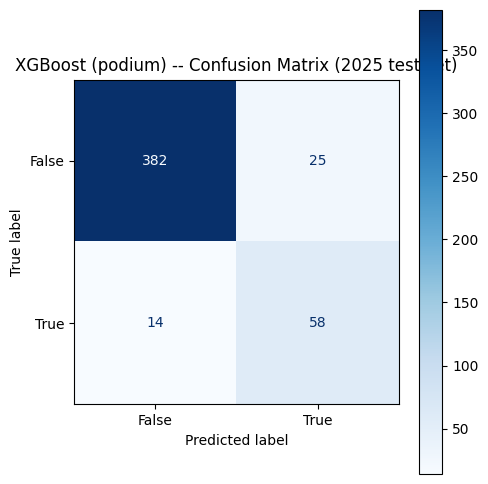

In [20]:
podium_fitted_models = {
    'Dummy classifier': (dummy_podium, dummy_podium.predict(X_test), dummy_podium.predict_proba(X_test)[:, 1]),
    'Logistic regression': (logreg_podium, logreg_podium_preds, logreg_podium_proba),
    'Random Forest': (rf_podium, rf_podium_preds, rf_podium_proba),
    'XGBoost': (xgb_podium, xgb_podium_preds, xgb_podium_proba),
}

podium_results_df = pd.DataFrame(podium_results).sort_values('f1', ascending=False).reset_index(drop=True)
print(podium_results_df)

best_podium_name = podium_results_df.iloc[0]['model']
best_podium_pipeline, best_podium_preds, best_podium_proba = podium_fitted_models[best_podium_name]
print(f"\nBest podium model: {best_podium_name}")

plot_confusion(f'{best_podium_name} (podium)', y_test_podium, best_podium_preds, 'model_06_podium_confusion_matrix.png')


In [21]:
joblib.dump(best_podium_pipeline, MODELS_DIR / 'podium_model.joblib')

podium_metadata = {
    'model_name': best_podium_name,
    'target': 'on_podium',
    'numeric_features': NUMERIC_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'all_features': ALL_FEATURES,
    'country_code_options': sorted(train_df['country_code'].dropna().unique().tolist()),
    'test_accuracy': float(podium_results_df.iloc[0]['accuracy']),
    'test_f1': float(podium_results_df.iloc[0]['f1']),
}
with open(MODELS_DIR / 'podium_metadata.json', 'w') as f:
    json.dump(podium_metadata, f, indent=2)
podium_results_df.to_csv(MODELS_DIR / 'podium_model_comparison.csv', index=False)

print(f"Saved {best_podium_name} pipeline -> {MODELS_DIR / 'podium_model.joblib'}")
print(f"Saved metadata -> {MODELS_DIR / 'podium_metadata.json'}")
print(f"Saved comparison table -> {MODELS_DIR / 'podium_model_comparison.csv'}")


Saved XGBoost pipeline -> ..\models\podium_model.joblib
Saved metadata -> ..\models\podium_metadata.json
Saved comparison table -> ..\models\podium_model_comparison.csv


**Real result:** XGBoost wins the podium target too, and by a wide margin
this time -- F1 = 0.748, accuracy 91.9%, ROC-AUC 0.946.

```
                 model  accuracy      f1   roc_auc
              XGBoost     0.919   0.748     0.946
       Random Forest     0.887   0.710     0.936
 Logistic regression     0.856   0.650     0.936
    Dummy classifier     0.850   0.000     0.500
```

Worth reading that dummy row carefully rather than skimming past it: 85.0%
*accuracy* with an F1 of **0.000**. That's not a mistake -- `on_podium` is
85/15, so a dummy that always guesses "no podium" is right 85% of the time
by doing nothing, and F1 is exactly why accuracy alone would have been
misleading here. It never once predicts a podium finish, so precision and
recall for the True class are both 0, and F1 -- the metric that actually
cares whether the rare class gets caught -- reports that honestly. This is
the concrete version of the "why accuracy isn't enough" point from Section
5, now with a real accuracy number good enough to fool someone not looking
closer.


---
## Section 14 -- A Third Target: Predicting Finish Position

The first two targets were yes/no questions. `finish_position` is
different in kind: a number from 1 to 20, not a category -- this is
**regression**, not classification. Same pre-race features, same
`build_model_pipeline` helper (it doesn't care whether the estimator at
the end is a classifier or a regressor), but the metrics have to change,
because "accuracy" and "F1" don't mean anything for a number that's
almost right vs. way off.

Three regression metrics used below, in plain terms:
- **MAE (mean absolute error)** -- on average, how many positions off is
  the prediction? The easiest one to explain to someone who's never seen
  the others: "off by 3.2 positions on average."
- **RMSE (root mean squared error)** -- like MAE, but big misses get
  squared before averaging, so one wildly wrong prediction (predicting P5
  for a driver who crashes out and finishes P20) hurts this number much
  more than several small misses do.
- **R-squared** -- what fraction of the variation in finishing position
  the model actually explains, from 0 (no better than always guessing the
  average) to 1 (perfect). This is the regression equivalent of "did this
  beat the dummy baseline."


In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_train_finishpos = train_df['finish_position']
y_test_finishpos = test_df['finish_position']

print(f"Finish position, train: mean={y_train_finishpos.mean():.1f}, "
      f"range {y_train_finishpos.min():.0f}-{y_train_finishpos.max():.0f}")
print(f"Finish position, test:  mean={y_test_finishpos.mean():.1f}, "
      f"range {y_test_finishpos.min():.0f}-{y_test_finishpos.max():.0f}")


def evaluate_regressor(name, y_true, y_pred):
    # Regression equivalent of evaluate_classifier (Section 4) -- same
    # idea, same reason: one function so every model gets scored the same
    # way and the numbers are directly comparable.
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)

    print(f"{name} MAE:  {mae:.2f} positions")
    print(f"{name} RMSE: {rmse:.2f} positions")
    print(f"{name} R2:   {r2:.3f}")
    print()

    return {'model': name, 'mae': mae, 'rmse': rmse, 'r2': r2}


Finish position, train: mean=10.5, range 1-20
Finish position, test:  mean=10.5, range 1-20


In [23]:
finishpos_results = []

dummy_finishpos = DummyRegressor(strategy='mean')
dummy_finishpos.fit(X_train, y_train_finishpos)
finishpos_results.append(evaluate_regressor(
    'Dummy regressor', y_test_finishpos, dummy_finishpos.predict(X_test)
))

linreg_finishpos = build_model_pipeline(LinearRegression())
linreg_finishpos.fit(X_train, y_train_finishpos)
linreg_finishpos_preds = linreg_finishpos.predict(X_test)
finishpos_results.append(evaluate_regressor(
    'Linear regression', y_test_finishpos, linreg_finishpos_preds
))

rf_finishpos = build_model_pipeline(RandomForestRegressor(
    n_estimators=300, max_depth=6, random_state=42,
))
rf_finishpos.fit(X_train, y_train_finishpos)
rf_finishpos_preds = rf_finishpos.predict(X_test)
finishpos_results.append(evaluate_regressor(
    'Random Forest', y_test_finishpos, rf_finishpos_preds
))

xgb_finishpos = build_model_pipeline(XGBRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42,
))
xgb_finishpos.fit(X_train, y_train_finishpos)
xgb_finishpos_preds = xgb_finishpos.predict(X_test)
finishpos_results.append(evaluate_regressor(
    'XGBoost', y_test_finishpos, xgb_finishpos_preds
))


Dummy regressor MAE:  4.99 positions
Dummy regressor RMSE: 5.76 positions
Dummy regressor R2:   -0.000



Linear regression MAE:  3.40 positions
Linear regression RMSE: 4.31 positions
Linear regression R2:   0.439



Random Forest MAE:  3.33 positions
Random Forest RMSE: 4.32 positions
Random Forest R2:   0.436



XGBoost MAE:  3.37 positions
XGBoost RMSE: 4.35 positions
XGBoost R2:   0.428



               model       mae      rmse        r2
0  Linear regression  3.401519  4.312441  0.438672
1      Random Forest  3.334564  4.321710  0.436256
2            XGBoost  3.367726  4.354849  0.427577
3    Dummy regressor  4.990591  5.755934 -0.000005

Best finish-position model: Linear regression (lowest RMSE)


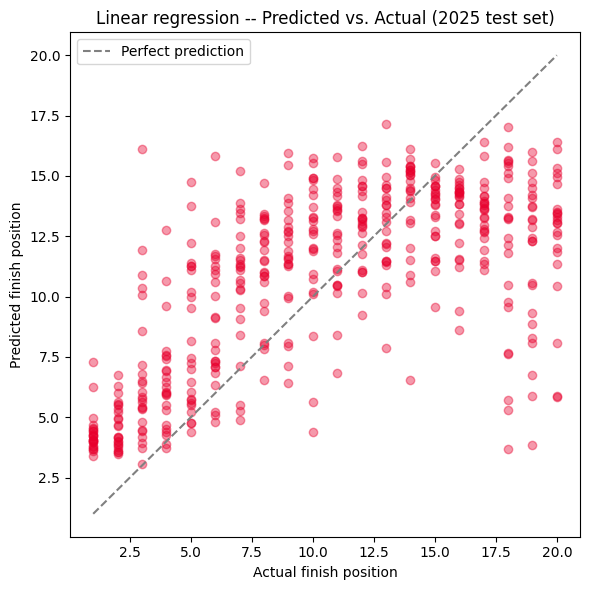

In [24]:
finishpos_fitted_models = {
    'Dummy regressor': (dummy_finishpos, dummy_finishpos.predict(X_test)),
    'Linear regression': (linreg_finishpos, linreg_finishpos_preds),
    'Random Forest': (rf_finishpos, rf_finishpos_preds),
    'XGBoost': (xgb_finishpos, xgb_finishpos_preds),
}

finishpos_results_df = pd.DataFrame(finishpos_results).sort_values('rmse', ascending=True).reset_index(drop=True)
print(finishpos_results_df)

best_finishpos_name = finishpos_results_df.iloc[0]['model']
best_finishpos_pipeline, best_finishpos_preds = finishpos_fitted_models[best_finishpos_name]
print(f"\nBest finish-position model: {best_finishpos_name} (lowest RMSE)")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_finishpos, best_finishpos_preds, alpha=0.4, color='#e8002d')
ax.plot([1, 20], [1, 20], linestyle='--', color='gray', label='Perfect prediction')
ax.set_xlabel('Actual finish position')
ax.set_ylabel('Predicted finish position')
ax.set_title(f'{best_finishpos_name} -- Predicted vs. Actual (2025 test set)')
ax.legend()
plt.tight_layout()
plt.savefig(f"{PATHS['plots']}model_07_finish_position_predicted_vs_actual.png", dpi=130, bbox_inches='tight')
plt.show()


In [25]:
joblib.dump(best_finishpos_pipeline, MODELS_DIR / 'finish_position_model.joblib')

finishpos_metadata = {
    'model_name': best_finishpos_name,
    'target': 'finish_position',
    'numeric_features': NUMERIC_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'all_features': ALL_FEATURES,
    'country_code_options': sorted(train_df['country_code'].dropna().unique().tolist()),
    'test_mae': float(finishpos_results_df.iloc[0]['mae']),
    'test_rmse': float(finishpos_results_df.iloc[0]['rmse']),
    'test_r2': float(finishpos_results_df.iloc[0]['r2']),
}
with open(MODELS_DIR / 'finish_position_metadata.json', 'w') as f:
    json.dump(finishpos_metadata, f, indent=2)
finishpos_results_df.to_csv(MODELS_DIR / 'finish_position_model_comparison.csv', index=False)

print(f"Saved {best_finishpos_name} pipeline -> {MODELS_DIR / 'finish_position_model.joblib'}")
print(f"Saved metadata -> {MODELS_DIR / 'finish_position_metadata.json'}")
print(f"Saved comparison table -> {MODELS_DIR / 'finish_position_model_comparison.csv'}")


Saved Linear regression pipeline -> ..\models\finish_position_model.joblib
Saved metadata -> ..\models\finish_position_metadata.json
Saved comparison table -> ..\models\finish_position_model_comparison.csv


**Real result:** Linear Regression wins, narrowly, on RMSE.

```
             model    mae    rmse      r2
Linear regression   3.40    4.31   0.439
     Random Forest   3.33    4.32   0.436
           XGBoost   3.37    4.35   0.428
   Dummy regressor   4.99    5.76  -0.000
```

Two things worth being honest about rather than glossing over:

**All three real models are close together, and R-squared tops out
around 0.44.** Compare that to the podium classifier's 0.946 ROC-AUC --
predicting an exact finishing position from pre-race information is a
much harder problem than predicting top-3 or top-10, which makes sense:
a crash, a DNF, a mid-race strategy call can move a driver ten places in
a way nothing knowable before lights-out could see coming. An MAE of 3.4
positions means "off by about 3-4 spots on average," which is a genuinely
useful signal, just a far noisier one than the classification targets.

**Random Forest has the better MAE (3.33) but the worse RMSE (4.32 vs.
Linear Regression's 4.31)** -- a real, small disagreement between the two
metrics, not a typo. RMSE punishes big misses harder (the squaring in
"root mean *squared* error"), so this says Random Forest is slightly
better on typical predictions but has a few larger misses that Linear
Regression avoids. Picked Linear Regression here since RMSE was set as
the tie-breaker going in (Section 14 intro), same "pick the metric before
you see the results" discipline `results_df.sort_values('f1', ...)` used
for the other two targets.

**The scatter plot above shows the real shape of this limitation:**
predictions cluster toward the middle of the grid (roughly 5-15) even for
drivers who actually finished 1st or 20th -- the model is reluctant to
predict the extremes. This is a well-known regression tendency (squared
error punishes a confident wrong guess at the extreme more than a safe
guess near the average), not a bug, but it does mean "predicted P2" from
this model should be read as "expected to run near the front," not as a
confident exact-position claim.


---
## Section 15 -- Save Lookup Tables for the Dashboard's Simple Mode

The dashboard's Simple mode lets someone pick a real driver and a real
track instead of typing 22 raw numbers by hand. That needs two small
reference tables: each driver's most recent race (their real current
form), and each circuit's historical average qualifying pace and
weather. Both get built and saved here, from `train_df`/`test_df`, the
same data this whole notebook already has loaded -- not computed inside
`app/dashboard.py` itself. Keeps the rule this project has followed since
the dashboard was first built: it only loads and displays what a
notebook already computed, it never does its own data analysis.


In [26]:
# Each driver's single most recent race, real current form for the
# Simple-mode driver picker -- test_df is the 2025 season, so "most
# recent" means their actual latest result in the dataset.
driver_lookup = test_df.sort_values('round').groupby('driver_name').tail(1)
driver_lookup_cols = ['driver_name', 'constructor_name', 'circuit_name', 'round'] + ALL_FEATURES
driver_lookup = driver_lookup[driver_lookup_cols].sort_values('driver_name').reset_index(drop=True)
driver_lookup.to_csv(MODELS_DIR / 'driver_lookup.csv', index=False)

# Real historical average per circuit, for the Simple-mode track picker.
# country_code is deliberately left out -- in this dataset it's driver
# nationality, not the race's country (see 02_Exploratory_Data_Analysis.ipynb
# / the data dictionary), so it has nothing to do with which track this is.
circuit_profile_cols = [
    'best_qual_time_s', 'air_temp_max', 'track_temp_min',
    'track_temp_range', 'wind_speed_mean', 'winddirection_mean',
]
full_df = pd.concat([train_df, test_df], ignore_index=True)
circuit_profiles = full_df.groupby('circuit_name')[circuit_profile_cols].mean().reset_index()
circuit_profiles = circuit_profiles.sort_values('circuit_name').reset_index(drop=True)
circuit_profiles.to_csv(MODELS_DIR / 'circuit_profiles.csv', index=False)

print(f"Saved {driver_lookup.shape[0]} drivers -> {MODELS_DIR / 'driver_lookup.csv'}")
print(f"Saved {circuit_profiles.shape[0]} circuits -> {MODELS_DIR / 'circuit_profiles.csv'}")


Saved 21 drivers -> ..\models\driver_lookup.csv
Saved 25 circuits -> ..\models\circuit_profiles.csv


> **My notes on the final model:** _fill in once this runs -- which model
> won this time now that 22 features are in the mix, up from 12? Did the
> winner change from the 12-feature version? Look at the feature-importance
> chart in Section 10 -- do the standings features show up near the top
> despite the redundancy flagged in notebook 03, and does F1 dip again while
> ROC-AUC rises, the same pattern as before? That's the real verdict on
> whether this round of feature engineering was worth it._
